## import

In [1]:
import pandas as pd
import tensorflow as tf
import tensorflow_recommenders as tfrs
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# --- 랜덤 시드 고정 ---
SEED = 1
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

/Users/jyc/Desktop/DEV/projects/capstone_rta/rta-recommend/rta-venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 데이터 로드 및 TensorFlow 데이터셋 생성

In [2]:
# 1. 학습 데이터 불러오기
train_df = pd.read_csv('../data/processed/train_data.csv')
train_df.head()

,user_id,store_id,category,contents,time,meal_time,meal_time_code,day_of_week,is_weekend,is_holiday,is_positive
0,132,12940,6,매우맛있음. 배달도 센스있음. 주문사항은 좀더 잘 반영해주시면 좋겠음.,2024-01-28 18:37:00,dinner,2,6,1,0,1
1,33,5345,2,맛있게 잘먹었습니다,2024-11-03 08:45:00,breakfast,0,6,1,0,1
2,369,7796,13,가격대비 나쁘지 않음!!!,2024-04-17 22:03:00,late_night_snack,3,2,0,0,1
3,195,10187,13,빠른 배송 감사합니다. 맛있어요,2023-12-23 09:18:00,breakfast,0,5,1,0,1
4,191,2866,9,보통맛도 맵다는 후기가 많아서 걱정했는데 매운거 좀 먹으시는 분들은 더 맵게 드셔도...,2025-07-12 22:23:00,late_night_snack,3,5,1,0,1


In [3]:
# 2. dataframe을 tensorflow dataset으로 변환
# interaction 데이터와 label 분리

interactions_dict = {name: np.array(value) for name, value in train_df.items()}
labels = interactions_dict.pop('is_positive')

dataset = tf.data.Dataset.from_tensor_slices((interactions_dict, labels))

In [4]:
# 3. 데이터셋 확인: 1개의 데이터 샘플
for x, y in dataset.take(1):
    print('--- 입력 feature ---')
    for key, value in x.items():
        print(f"    {key}: {value}")
    print("\n--- 정답 label ---")
    print(f"    is_positive: {y}")

--- 입력 feature ---
    user_id: 132
    store_id: 12940
    category: 6
    contents: b'\xeb\xa7\xa4\xec\x9a\xb0\xeb\xa7\x9b\xec\x9e\x88\xec\x9d\x8c. \xeb\xb0\xb0\xeb\x8b\xac\xeb\x8f\x84 \xec\x84\xbc\xec\x8a\xa4\xec\x9e\x88\xec\x9d\x8c. \xec\xa3\xbc\xeb\xac\xb8\xec\x82\xac\xed\x95\xad\xec\x9d\x80 \xec\xa2\x80\xeb\x8d\x94 \xec\x9e\x98 \xeb\xb0\x98\xec\x98\x81\xed\x95\xb4\xec\xa3\xbc\xec\x8b\x9c\xeb\xa9\xb4 \xec\xa2\x8b\xea\xb2\xa0\xec\x9d\x8c.'
    time: b'2024-01-28 18:37:00'
    meal_time: b'dinner'
    meal_time_code: 2
    day_of_week: 6
    is_weekend: 1
    is_holiday: 0

--- 정답 label ---
    is_positive: 1


## 고유값 추출

In [5]:
# 각 feature의 고유값 추출하여 배열에 저장
user_ids = train_df["user_id"].unique()
store_ids = train_df["store_id"].unique()
meal_time_codes = train_df["meal_time_code"].unique()
day_of_weeks = train_df["day_of_week"].unique()
categories = train_df["category"].unique()

print("--- 각 피처의 고유값 개수 ---")
print(f"User ID: {len(user_ids)}개")
print(f"Store ID: {len(store_ids)}개")
print(f"Meal Time Code: {len(meal_time_codes)}개")
print(f"Day of Week: {len(day_of_weeks)}개")
print(f"Category: {len(categories)}개")

--- 각 피처의 고유값 개수 ---
User ID: 370개
Store ID: 114개
Meal Time Code: 4개
Day of Week: 7개
Category: 12개


## User Tower, Item Tower 구현

In [6]:
# 벡터의 크기 정의
embedding_dimension = 32

### User Tower

In [7]:
user_model = tf.keras.Sequential([
    # user_id를 정수 인덱스로 변환
    tf.keras.layers.IntegerLookup(vocabulary=user_ids, mask_token=None),
    # 정수 인덱스를 32차원의 벡터로 변환
    tf.keras.layers.Embedding(len(user_ids) + 1, embedding_dimension)
])

### Item Tower

In [8]:
# Item Tower 확장 (store_id, category)
# Keras - Functional API (여러 입력 처리 목적)
store_id_input = tf.keras.Input(shape=(), name='store_id', dtype=tf.int64)
category_input = tf.keras.Input(shape=(), name='category', dtype=tf.int64)

# 각 입력 피처를 위한 임베딩 파이프라인
store_embedding = tf.keras.Sequential([
    tf.keras.layers.IntegerLookup(vocabulary=store_ids, mask_token=None),
    tf.keras.layers.Embedding(len(store_ids) + 1, embedding_dimension)
])(store_id_input)

category_embedding = tf.keras.Sequential([
    tf.keras.layers.IntegerLookup(vocabulary=categories, mask_token=None),
    tf.keras.layers.Embedding(len(categories) + 1, embedding_dimension)
])(category_input)

# 두 임베딩 벡터를 하나로 결합
concatenated_item_embeddings = tf.keras.layers.Concatenate()([
    store_embedding,
    category_embedding
])

# Dense 레이어로 피처 간 상호작용 학습 후 최종 벡터 생성
final_item_vector = tf.keras.layers.Dense(embedding_dimension, activation="relu")(concatenated_item_embeddings)

# 최종 Item Tower 모델
item_model = tf.keras.Model(
    inputs={
        "store_id": store_id_input,
        "category": category_input
    },
    outputs=final_item_vector
)

### Two Tower Model 정의

In [9]:
# 후보군 데이터셋을 확장된 Item Tower를 사용해 다시 생성
all_stores_df = train_df[["store_id", "category"]].drop_duplicates()
all_stores_dataset = tf.data.Dataset.from_tensor_slices({
    "store_id": all_stores_df["store_id"].values,
    "category": all_stores_df["category"].values
})
candidates_dataset = all_stores_dataset.batch(128).map(lambda x: item_model(x))

# TwoTowerModel 클래스 정의
class TwoTowerModel(tfrs.Model):

    def __init__(self, user_model, item_model, candidates):
        super().__init__()
        self.user_model = user_model
        self.item_model = item_model
        
        self.task = tfrs.tasks.Retrieval(
            metrics=tfrs.metrics.FactorizedTopK(
                candidates=candidates
            )
        )

    def compute_loss(self, data, training=False):
        features = data[0]
        user_embeddings = self.user_model(features["user_id"]) # User Tower는 동일
        
        item_embeddings = self.item_model({    # 딕셔너리 형태의 item tower 입력
            "store_id": features["store_id"],
            "category": features["category"],
        })
        
        return self.task(user_embeddings, item_embeddings, compute_metrics=not training)

## 학습
### 모델 인스턴스화, 컴파일

### 데이터셋 준비, batch 처리

In [10]:
# 1. 데이터셋 크기 계산 및 분할
tf.random.set_seed(42)
shuffled = dataset.shuffle(len(train_df), seed=42, reshuffle_each_iteration=False)

# 80%:학습+검증용, 20%: 테스트용
train_val_size = int(len(train_df) * 0.8)
train_val_dataset = shuffled.take(train_val_size)
test_dataset = shuffled.skip(train_val_size)

# 학습+검증용 데이터셋을 8:2 비율로 나누어 최종 학습/검증용으로 분할
validation_size = int(train_val_size * 0.2)
train_dataset = train_val_dataset.skip(validation_size)
validation_dataset = train_val_dataset.take(validation_size)

# 2. 각 데이터셋을 배치 처리
train_dataset = train_dataset.batch(128).cache().prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.batch(128).cache().prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(128).cache().prefetch(tf.data.AUTOTUNE)

### 학습 시작

In [11]:
# 1. 조기 종료 콜백 정의
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# 2. 모델 객체 생성 시 candidates_dataset을 전달
model = TwoTowerModel(user_model, item_model, candidates=candidates_dataset)

# 3. 모델 컴파일
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

# 4. 모델 학습
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=[early_stopping_callback]
)

# 5. 최종 성능 평가
print("\n--- 최종 테스트 성능 ---")
test_metrics = model.evaluate(test_dataset, return_dict=True)
print(test_metrics)

Epoch 1/50
16/16 [==============================] - 1s 29ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_10_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_50_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_100_categorical_accuracy: 0.0000e+00 - loss: 550.7125 - regularization_loss: 0.0000e+00 - total_loss: 550.7125 - val_factorized_top_k/top_1_categorical_accuracy: 0.0021 - val_factorized_top_k/top_5_categorical_accuracy: 0.0332 - val_factorized_top_k/top_10_categorical_accuracy: 0.0830 - val_factorized_top_k/top_50_categorical_accuracy: 0.3921 - val_factorized_top_k/top_100_categorical_accuracy: 0.8091 - val_loss: 449.3050 - val_regularization_loss: 0.0000e+00 - val_total_loss: 449.3050
Epoch 2/50
16/16 [==============================] - 0s 7ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0000e+00 - factorized_top_k/top_5_categorical_accuracy: 0.0000e+00 - facto

### 결과 시각화

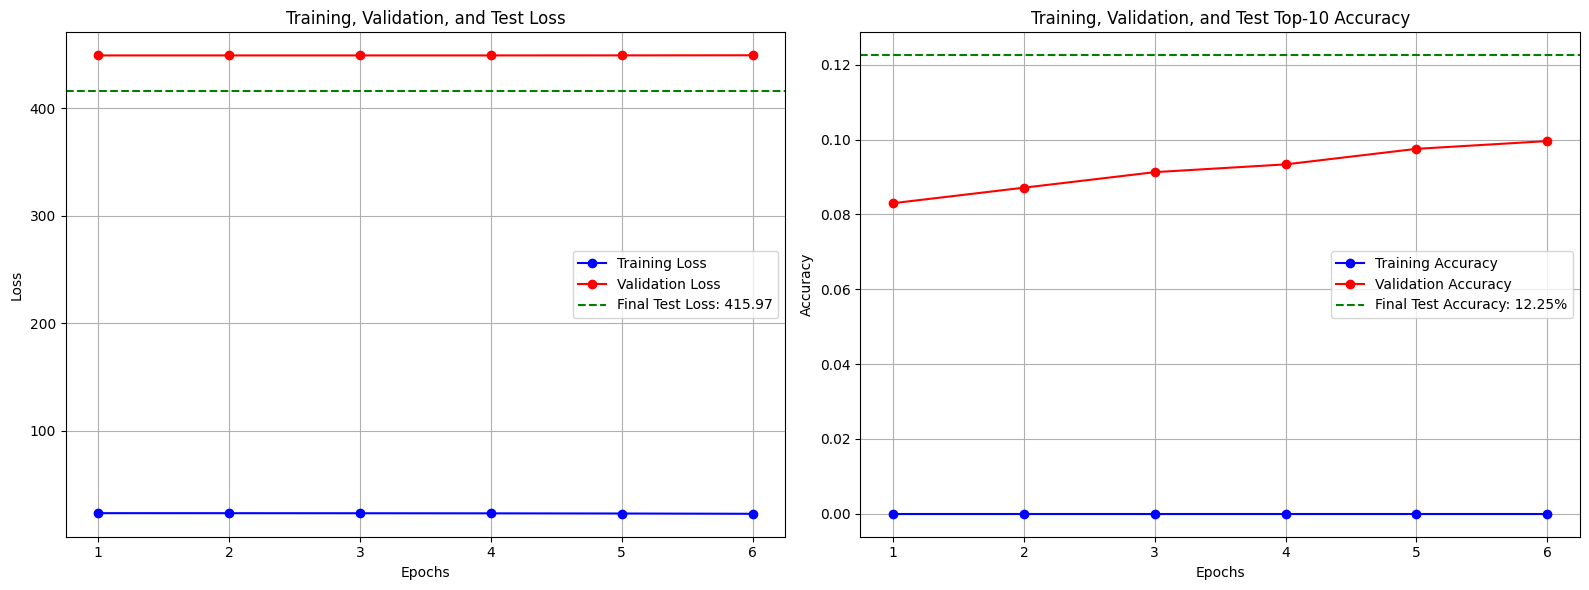

In [12]:
import matplotlib.pyplot as plt

# --- 1. history 객체와 test_metrics에서 모든 값 추출 ---

history_dict = history.history

# 손실(Loss) 값들
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']
final_test_loss = test_metrics['loss']

# Top-10 정확도(Accuracy) 값들
train_acc_key = 'factorized_top_k/top_10_categorical_accuracy'
val_acc_key = 'val_factorized_top_k/top_10_categorical_accuracy'
test_acc_key = 'factorized_top_k/top_10_categorical_accuracy'

train_accuracy = history_dict[train_acc_key]
val_accuracy = history_dict[val_acc_key]
final_test_accuracy = test_metrics[test_acc_key]

epochs = range(1, len(train_loss) + 1)

# --- 2. 종합 비교 그래프 시각화 ---

plt.figure(figsize=(16, 6))

# --- Loss 비교 그래프 (학습 + 검증 + 최종 테스트) ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss') # 학습 손실 (파란색 선)
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss') # 검증 손실 (빨간색 선)
plt.axhline(y=final_test_loss, color='g', linestyle='--', label=f'Final Test Loss: {final_test_loss:.2f}') # 최종 테스트 손실 (초록색 점선)
plt.title('Training, Validation, and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Top-10 Accuracy 비교 그래프 (학습 + 검증 + 최종 테스트) ---
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, 'bo-', label='Training Accuracy') # 학습 정확도 (파란색 선)
plt.plot(epochs, val_accuracy, 'ro-', label='Validation Accuracy') # 검증 정확도 (빨간색 선)
plt.axhline(y=final_test_accuracy, color='g', linestyle='--', label=f'Final Test Accuracy: {final_test_accuracy*100:.2f}%') # 최종 테스트 정확도 (초록색 점선)
plt.title('Training, Validation, and Test Top-10 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 모델 저장 / 가게 벡터 사전 계산 및 저장

In [13]:
# --- 모델 저장---

# 1. 경로 생성
save_dir = './saved_models/experiment_2'
os.makedirs(save_dir, exist_ok=True)

# 2. User Tower 저장 (베이스라인과 동일)
model.user_model.save(os.path.join(save_dir, 'user_model'))

# 3. 확장된 Item Tower 저장
model.item_model.save(os.path.join(save_dir, 'item_model'))

print(f"--- User Tower, Item Tower 저장 완료 ---\n'{save_dir}'\n")


# --- 전체 가게 벡터 사전 계산 및 저장 ---

# 4. 모든 가게의 'store_id'와 'category'를 포함하는 데이터셋
all_stores_df = train_df[["store_id", "category"]].drop_duplicates().sort_values("store_id").reset_index(drop=True)
all_stores_dataset_for_predict = tf.data.Dataset.from_tensor_slices({
    "store_id": all_stores_df["store_id"].values,
    "category": all_stores_df["category"].values
})

# 5. 확장된 item_model을 이용해 모든 벡터를 미리 계산.
all_item_embeddings = model.item_model.predict(all_stores_dataset_for_predict.batch(128))

# 6. NumPy 파일로 저장
np.save(os.path.join(save_dir, 'all_item_embeddings.npy'), all_item_embeddings)

# 7. 정렬된 store_ids 배열 저장
np.save(os.path.join(save_dir, 'all_store_ids.npy'), all_stores_df["store_id"].values)

print(f"--- {len(all_item_embeddings)}개의 가게 벡터 계산 완료---\n'{save_dir}'\n")

INFO:tensorflow:Assets written to: ./saved_models/experiment_2/user_model/assets


INFO:tensorflow:Assets written to: ./saved_models/experiment_2/user_model/assets


INFO:tensorflow:Assets written to: ./saved_models/experiment_2/item_model/assets


INFO:tensorflow:Assets written to: ./saved_models/experiment_2/item_model/assets


--- User Tower, Item Tower 저장 완료 ---
'./saved_models/experiment_2'

1/1 [==============================] - 0s 61ms/step
--- 115개의 가게 벡터 계산 완료---
'./saved_models/experiment_2'

